在这个工作是是将航班频次作为边的权重

## 加载数据

In [1]:
import pandas as pd

# 加载数据
data = pd.read_csv('../../data-hh/my/hh_result/result_2023_2024_05.csv')


# 查看前几行数据，确保加载成功
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5937179 entries, 0 to 5937178
Data columns (total 21 columns):
 #   Column      Dtype  
---  ------      -----  
 0   flt_no      object 
 1   bd_type     object 
 2   cap         float64
 3   aircraft    object 
 4   legs        int64  
 5   leg_no      int64  
 6   duration    float64
 7   pax         int64  
 8   a           object 
 9   b           object 
 10  c           object 
 11  year        int64  
 12  month       int64  
 13  day         int64  
 14  weekday     int64  
 15  hour        int64  
 16  minute      int64  
 17  second      int64  
 18  from        object 
 19  to          object 
 20  unit_price  float64
dtypes: float64(3), int64(10), object(8)
memory usage: 951.2+ MB
None


## 生成加权图

In [2]:
# 创建一个新的数据框，用于存储航班频数
flight_counts = data.groupby(['from', 'to']).size().reset_index(name='flight_count')

# 打印查看
print(flight_counts.shape)
print(flight_counts.head())


(7977, 3)
           from            to  flight_count
0  +3eoTOkHfoU=  0Koyk9pJc0s=            90
1  +3eoTOkHfoU=  4j3sFPu6XuA=            56
2  +3eoTOkHfoU=  9obCP1myMDU=           146
3  +3eoTOkHfoU=  AqmhSoBTk6M=             3
4  +3eoTOkHfoU=  CnmNtb5MOJA=           116


In [3]:
import networkx as nx

# 创建一个空图
G = nx.Graph()

# 将城市作为节点，航班频数作为边的权重添加到图中
for index, row in flight_counts.iterrows():
    G.add_edge(row['from'], row['to'], weight=row['flight_count'])

# 输出图的基本信息
print("图的节点数:", G.number_of_nodes())
print("图的边数:", G.number_of_edges())

图的节点数: 252
图的边数: 4031


/Users/zhanyu/opt/anaconda3/envs/machine/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 21152 (\N{CJK UNIFIED IDEOGRAPH-52A0}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/zhanyu/opt/anaconda3/envs/machine/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 26435 (\N{CJK UNIFIED IDEOGRAPH-6743}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/zhanyu/opt/anaconda3/envs/machine/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 33322 (\N{CJK UNIFIED IDEOGRAPH-822A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/zhanyu/opt/anaconda3/envs/machine/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 29677 (\N{CJK UNIFIED IDEOGRAPH-73ED}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/zhanyu/opt/anaconda3/envs/machine/lib/python3.10/

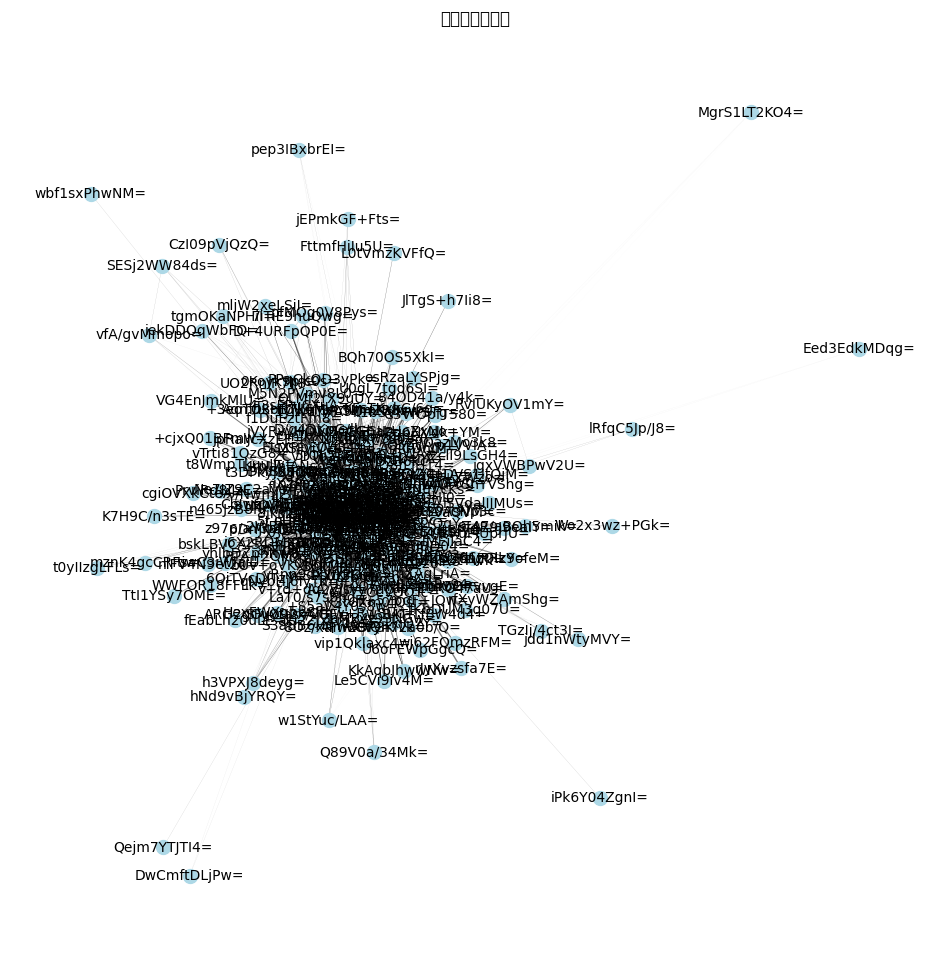

In [4]:
import matplotlib.pyplot as plt

# 设置图的布局
plt.figure(figsize=(12, 12))

# 绘制加权图，边的宽度表示航班频数
pos = nx.spring_layout(G, k=0.5)  # 使用 spring 布局来可视化图
edges = G.edges(data=True)

# 绘制节点
nx.draw_networkx_nodes(G, pos, node_size=100, node_color='lightblue')

# 绘制边，边的宽度表示航班频数（weight）
nx.draw_networkx_edges(G, pos, width=[d['weight'] / 1000 for u, v, d in edges], alpha=0.5)

# 绘制节点标签
nx.draw_networkx_labels(G, pos, font_size=10)

# 显示图形
plt.title("加权航班网络图")
plt.axis('off')
plt.show()

## 创建并训练 DeepWalk 模型

In [5]:
import numpy
print(numpy.__version__)

1.26.4


In [6]:
import networkx as nx
from node2vec import Node2Vec

1. 加载图并准备数据

In [7]:
node2vec = Node2Vec(G, 
                   dimensions=64, 
                   walk_length=3, 
                   num_walks=200, 
                   workers=4,
                   weight_key='weight')

model = node2vec.fit(window=3, 
                    min_count=1, 
                    batch_words=4)

Computing transition probabilities:   0%|          | 0/252 [00:00<?, ?it/s]

Generating walks (CPU: 4): 100%|██████████| 50/50 [00:00<00:00, 399.96it/s]


2. 获取节点的嵌入向量

In [8]:
# 获取城市嵌入表示
city_embeddings = {}
for city in G.nodes():
    city_embeddings[city] = model.wv[city]  # 从模型中提取城市嵌入

# 打印第一个城市的嵌入表示
print(city_embeddings[list(G.nodes())[0]])

[ 2.09501833e-02 -4.57968146e-01 -1.15891062e-01  3.68158758e-01
  1.67309582e-01 -3.60698491e-01 -5.04750192e-01  5.21815680e-02
 -5.40268302e-01 -5.37439406e-01  7.48625636e-01 -5.89922309e-01
 -1.96025968e-01 -3.18735808e-01  2.37408146e-01  3.62991750e-01
  2.11186439e-01 -2.62829214e-01  3.73992532e-01  6.24128710e-03
  1.08687438e-01  9.31028605e-01  5.64044595e-01 -3.20549995e-01
  9.50278789e-02 -9.64296758e-02  3.32267769e-02  6.55185282e-02
 -3.93275440e-01 -3.32784712e-01  1.52535336e-02 -2.68310189e-01
 -1.55889452e-01 -3.97367477e-01 -3.87818813e-01 -1.58407837e-01
  2.99999297e-01  1.86577961e-02  3.57241213e-01  1.11323044e-01
 -3.42978723e-02 -3.30677748e-01 -5.81325323e-04 -4.64538485e-01
  6.84102237e-01 -5.43094799e-02  2.72018015e-01 -1.72398686e-01
  4.00044143e-01  6.89593196e-01 -1.04676239e-01 -2.15851247e-01
  2.33659804e-01  2.83030480e-01  2.21488580e-01 -1.64659485e-01
  7.44604588e-01 -1.06068686e-01 -4.04027611e-01  5.61288118e-01
  2.82950103e-01 -2.63627

city_embeddings是一个字典

## 进行聚类

步骤 3：使用嵌入向量进行下游任务（例如聚类）

In [9]:
from sklearn.cluster import KMeans
import numpy as np

# 提取嵌入向量
embeddings = np.array([city_embeddings[city] for city in G.nodes()])

# 使用 KMeans 聚类
kmeans = KMeans(n_clusters=3, random_state=42)  # 设置簇的数量为3
kmeans.fit(embeddings)

# 查看每个城市的聚类标签
city_labels = dict(zip(G.nodes(), kmeans.labels_))

# 打印城市及其对应的聚类标签
for city, label in city_labels.items():
    print(f"城市: {city}, 聚类标签: {label}")


城市: +3eoTOkHfoU=, 聚类标签: 1
城市: 0Koyk9pJc0s=, 聚类标签: 1
城市: 4j3sFPu6XuA=, 聚类标签: 1
城市: 9obCP1myMDU=, 聚类标签: 2
城市: AqmhSoBTk6M=, 聚类标签: 1
城市: CnmNtb5MOJA=, 聚类标签: 0
城市: DInJHXgQayE=, 聚类标签: 1
城市: EIsXRbFUH34=, 聚类标签: 1
城市: M5N2PVmv8L0=, 聚类标签: 1
城市: MSFyivV4ETI=, 聚类标签: 1
城市: N4hmDZN/CJQ=, 聚类标签: 0
城市: UO2RniR7lJ8=, 聚类标签: 1
城市: XUXDuFGVfBM=, 聚类标签: 1
城市: ZCvDTbZuS8Q=, 聚类标签: 1
城市: gK3uAaRHrOs=, 聚类标签: 2
城市: jVYRvyHjuvM=, 聚类标签: 1
城市: +O1iBQtlFGU=, 聚类标签: 2
城市: /M8gHzjxpNU=, 聚类标签: 2
城市: 0J4jz5aCatU=, 聚类标签: 0
城市: AKQNtuL5r6Q=, 聚类标签: 0
城市: AlGb30xUGAU=, 聚类标签: 2
城市: C3VfOpfT580=, 聚类标签: 0
城市: Eg2bemFsI9I=, 聚类标签: 0
城市: FWD6O2fHsIU=, 聚类标签: 0
城市: KETr2NAmAHE=, 聚类标签: 2
城市: KFsTKxkC/6g=, 聚类标签: 0
城市: Qe7TEMbQt6o=, 聚类标签: 2
城市: QyEgIt0M8Sg=, 聚类标签: 0
城市: So/c8CkA/Xs=, 聚类标签: 2
城市: a2cXIUGpIbw=, 聚类标签: 2
城市: g1hKMyP1V8I=, 聚类标签: 0
城市: iX2Pe2pxiqQ=, 聚类标签: 2
城市: lI1bSVMW3Tg=, 聚类标签: 2
城市: mljW2xeLSiI=, 聚类标签: 2
城市: tKjndGSl9NQ=, 聚类标签: 2
城市: vbo2dwBOeps=, 聚类标签: 2
城市: yypkiQCX5lk=, 聚类标签: 2
城市: +S5aV4Y0s8w=, 聚类标签: 0
城市: Szk6NJM5

### 保存聚类标签

In [10]:
# 首先导入 json 模块
import json
print(city_labels)

# 将字典中的所有值转换为 Python 的原生 int 类型
city_labels = {key: int(value) for key, value in city_labels.items()}

# 保存字典到 JSON 文件
with open('../../data-hh/my/encoder/city_labels_航班频率加权图标签.json', 'w') as file:
    json.dump(city_labels, file)

print("字典已保存为 city_labels.json")

{'+3eoTOkHfoU=': 1, '0Koyk9pJc0s=': 1, '4j3sFPu6XuA=': 1, '9obCP1myMDU=': 2, 'AqmhSoBTk6M=': 1, 'CnmNtb5MOJA=': 0, 'DInJHXgQayE=': 1, 'EIsXRbFUH34=': 1, 'M5N2PVmv8L0=': 1, 'MSFyivV4ETI=': 1, 'N4hmDZN/CJQ=': 0, 'UO2RniR7lJ8=': 1, 'XUXDuFGVfBM=': 1, 'ZCvDTbZuS8Q=': 1, 'gK3uAaRHrOs=': 2, 'jVYRvyHjuvM=': 1, '+O1iBQtlFGU=': 2, '/M8gHzjxpNU=': 2, '0J4jz5aCatU=': 0, 'AKQNtuL5r6Q=': 0, 'AlGb30xUGAU=': 2, 'C3VfOpfT580=': 0, 'Eg2bemFsI9I=': 0, 'FWD6O2fHsIU=': 0, 'KETr2NAmAHE=': 2, 'KFsTKxkC/6g=': 0, 'Qe7TEMbQt6o=': 2, 'QyEgIt0M8Sg=': 0, 'So/c8CkA/Xs=': 2, 'a2cXIUGpIbw=': 2, 'g1hKMyP1V8I=': 0, 'iX2Pe2pxiqQ=': 2, 'lI1bSVMW3Tg=': 2, 'mljW2xeLSiI=': 2, 'tKjndGSl9NQ=': 2, 'vbo2dwBOeps=': 2, 'yypkiQCX5lk=': 2, '+S5aV4Y0s8w=': 0, 'Szk6NJM5C9Y=': 0, 'hwin1ipuzwk=': 2, 'nJFTk7JNmpw=': 2, 'wSF4qXvI044=': 0, 'xIqe+QQIQXQ=': 0, 'zwVGiYamVc0=': 0, '+cjxQ01BFmw=': 2, 'MeDwT1+vyYg=': 2, '/qxKZMQeBus=': 0, '07fT2dsZOJM=': 0, '1/9nd1jNCE0=': 0, '2WRfpdopfDw=': 0, '3nMB4t9SNGw=': 0, '4J2zqjPuTyI=': 2, '4Liydpz6+u

## 二维空间聚类效果展示

步骤 4：可视化嵌入

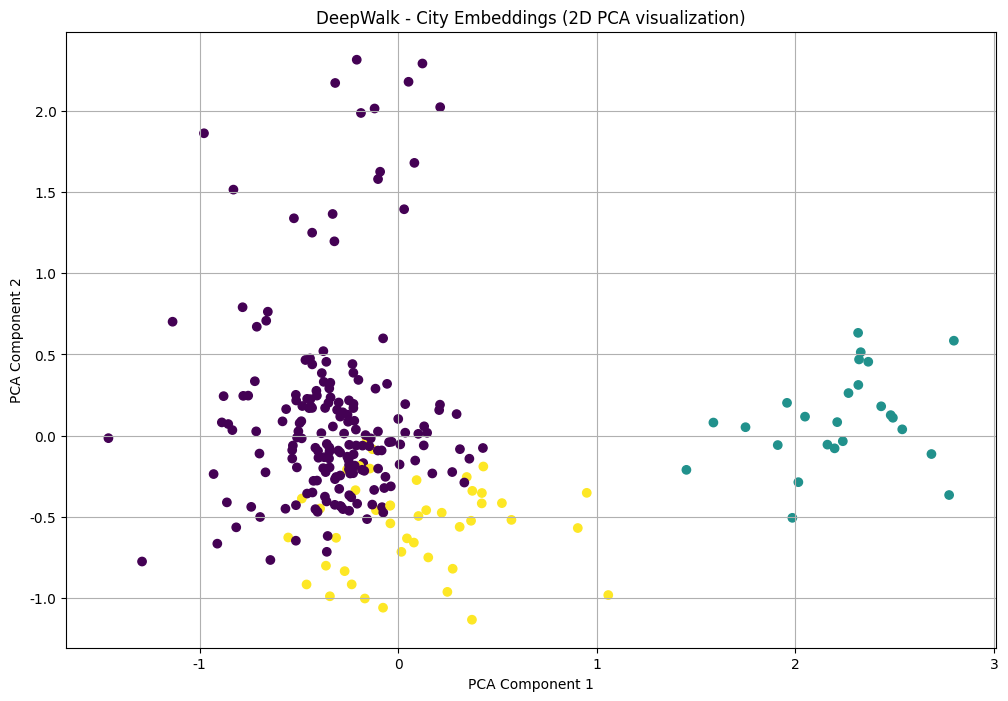

In [11]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 使用 PCA 降维到 2D
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(embeddings)

# 绘制散点图
plt.figure(figsize=(12, 8))
plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], c=kmeans.labels_, cmap='viridis')

# 去掉为每个城市添加标签的部分
# for i, city in enumerate(G.nodes()):
#     plt.text(reduced_embeddings[i, 0] + 0.1, reduced_embeddings[i, 1] + 0.1, city, fontsize=9)

plt.title("DeepWalk - City Embeddings (2D PCA visualization)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.show()


In [12]:
from sklearn.metrics.pairwise import cosine_similarity

# 计算城市之间的相似度
similarity_matrix = cosine_similarity(embeddings)

# 打印第一个城市和其他城市的相似度
for i, city in enumerate(G.nodes()):
    print(f"城市: {city}, 相似度: {similarity_matrix[0, i]}")

城市: +3eoTOkHfoU=, 相似度: 1.000000238418579
城市: 0Koyk9pJc0s=, 相似度: 0.887483537197113
城市: 4j3sFPu6XuA=, 相似度: 0.9717204570770264
城市: 9obCP1myMDU=, 相似度: 0.44717875123023987
城市: AqmhSoBTk6M=, 相似度: 0.9720005989074707
城市: CnmNtb5MOJA=, 相似度: 0.268578439950943
城市: DInJHXgQayE=, 相似度: 0.8928362131118774
城市: EIsXRbFUH34=, 相似度: 0.9808198809623718
城市: M5N2PVmv8L0=, 相似度: 0.9690322875976562
城市: MSFyivV4ETI=, 相似度: 0.9399204850196838
城市: N4hmDZN/CJQ=, 相似度: 0.5350158214569092
城市: UO2RniR7lJ8=, 相似度: 0.9678554534912109
城市: XUXDuFGVfBM=, 相似度: 0.760402500629425
城市: ZCvDTbZuS8Q=, 相似度: 0.9058511257171631
城市: gK3uAaRHrOs=, 相似度: 0.3865481913089752
城市: jVYRvyHjuvM=, 相似度: 0.9615442752838135
城市: +O1iBQtlFGU=, 相似度: 0.45888763666152954
城市: /M8gHzjxpNU=, 相似度: 0.16703081130981445
城市: 0J4jz5aCatU=, 相似度: 0.12843762338161469
城市: AKQNtuL5r6Q=, 相似度: 0.35234981775283813
城市: AlGb30xUGAU=, 相似度: 0.3721558451652527
城市: C3VfOpfT580=, 相似度: 0.555747926235199
城市: Eg2bemFsI9I=, 相似度: 0.47472116351127625
城市: FWD6O2fHsIU=, 相似度: 0.23478700

轮廓系数是评估聚类质量的常用指标，范围是 -1 到 1，值越大表示聚类效果越好。它同时考虑了簇内紧密度（每个点与所在簇中其他点的距离）和簇间分离度（每个点与最近簇的距离）。

值的意义：

值接近 +1：说明数据点与同簇内的点很接近，且与其他簇的点有很大区别，聚类效果好。

值接近 0：表示数据点可能位于两个簇的边界上，聚类效果一般。

值接近 -1：表示数据点可能被错误地归类到某个簇中，聚类效果差。

In [13]:
from sklearn.metrics import silhouette_score
score = silhouette_score(reduced_embeddings, kmeans.labels_)
print(f'Silhouette Score: {score}')

Silhouette Score: 0.25455403327941895


## 保存嵌入表示

In [14]:
import numpy as np
import json

# 获取城市列表
cities = list(city_embeddings.keys())

# 将降维后的嵌入表示转换为列表格式
reduced_embeddings_list = reduced_embeddings.tolist()

# 保存城市和其对应的嵌入（将 NumPy 数组转换为列表）
city_embedding_dict = {city: reduced_embeddings[i].tolist() for i, city in enumerate(cities)}

# 将 city_embedding_dict 保存为 JSON 文件
with open('../../data-hh/my/encoder/城市嵌入编码_航班频率加权图.json', 'w') as f:
    json.dump(city_embedding_dict, f)

print("城市嵌入表示已保存。")

城市嵌入表示已保存。


In [15]:
city_embedding_dict

{'+3eoTOkHfoU=': [2.048029899597168, 0.11681762337684631],
 '0Koyk9pJc0s=': [2.684593915939331, -0.11363507062196732],
 '4j3sFPu6XuA=': [2.1970198154449463, -0.07856795191764832],
 '9obCP1myMDU=': [-0.2154466211795807, -0.33637043833732605],
 'AqmhSoBTk6M=': [2.2669944763183594, 0.26208800077438354],
 'CnmNtb5MOJA=': [-0.4401859641075134, 0.17958064377307892],
 'DInJHXgQayE=': [2.3286147117614746, 0.5140590071678162],
 'EIsXRbFUH34=': [2.43149995803833, 0.18053443729877472],
 'M5N2PVmv8L0=': [2.1609177589416504, -0.055703360587358475],
 'MSFyivV4ETI=': [2.238361358642578, -0.03455201908946037],
 'N4hmDZN/CJQ=': [0.21004608273506165, 0.19061796367168427],
 'UO2RniR7lJ8=': [2.4795377254486084, 0.1261746883392334],
 'XUXDuFGVfBM=': [1.4508037567138672, -0.21108552813529968],
 'ZCvDTbZuS8Q=': [1.9107831716537476, -0.058400288224220276],
 'gK3uAaRHrOs=': [0.21883520483970642, -0.47537991404533386],
 'jVYRvyHjuvM=': [2.210099458694458, 0.08308106660842896],
 '+O1iBQtlFGU=': [0.94902735948562